In [61]:
from openpmd_api import Series, Access
import matplotlib.pyplot as plt
import numpy as np

In [69]:
series = Series("diags/diag/openpmd_%T.h5", Access.read_only)
its = sorted(series.iterations)
it = series.iterations[its[-1]]      # iteration 10

B = it.meshes["B"]
Bx = B["x"].load_chunk()
By = B["y"].load_chunk()
Bz = B["z"].load_chunk()
series.flush()
#B2 = Bx**2 + By**2 + Bz**2

shape  = B["x"].shape            # cells per axis, e.g. [Nz, Nr] in RZ
dx     = B.grid_spacing          # cell size along each axis
x0     = B.grid_global_offset    # lower corner of the grid
axes   = B.axis_labels           # e.g. ('z', 'r') or ('x','y','z')
unit   = B.grid_unit_SI          # multiply spacing/offset by this for meters
geom   = B.geometry              # cartesian / thetaMode / etc.

# physical extents (in SI meters)
lo = [o * unit for o in x0]
hi = [(o + n * d) * unit for o, n, d in zip(x0, shape, dx)]

coords = [x0[i]*unit + (np.arange(shape[i]) + B["x"].position[i]) * dx[i] * unit for i in range(len(shape))][0]

In [63]:
print(coords.shape)
print(Bx.shape)

(64,)
(64, 64)


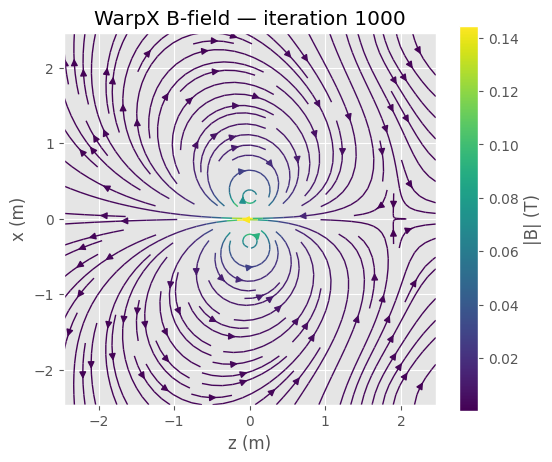

In [71]:
mag = np.hypot(Bx, Bz)

fig, ax = plt.subplots(figsize=(6, 5))
strm = ax.streamplot(
    coords, coords, Bx, Bz,
    color=mag, cmap="viridis", density=1.2, linewidth=1,
)
cb = fig.colorbar(strm.lines, ax=ax)
cb.set_label("|B| (T)")
ax.set_xlabel("z (m)")
ax.set_ylabel("x (m)")
ax.set_title(f"WarpX B-field — iteration {its[-1]}")
ax.set_aspect("equal")
plt.show()

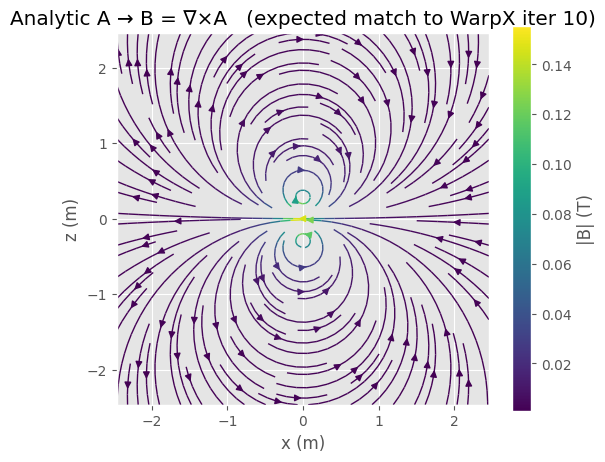

RMS rel error vs WarpX iter 10:
  Bx : 1.082e+00
  Bz : 5.912e-01
  |B|: 2.259e-01


In [65]:
# Constants from inputs/coil 2D/coil_2d.py (external_vector_potential.dipole):
#   K      vector-potential amplitude (T·m)
#   dh     half-separation between the two line currents (m)
#   eps    softening that keeps Ay finite on the line currents (m)
K   = 0.01
dh  = 0.25
eps = np.sqrt(0.006084)        # ≈ 0.078 m (matches eps² = 0.006084 in the run)


def Ay_analytic(x, z):
    """Static external A_y(x, z) used by the coil_2D run.

    Ax = Az = 0 by construction. Vectorised — `x` and `z` can be arrays of
    any matching shape.
    """
    return K * np.log(
        (x * x + (z + dh) ** 2 + eps * eps) /
        (x * x + (z - dh) ** 2 + eps * eps)
    )


# Build both axis coordinates from the openPMD metadata loaded earlier so
# the analytic grid is byte-identical to the WarpX one. axes[0] is x,
# axes[1] is z for this 2D Cartesian run.
xs = x0[0] * unit + (np.arange(shape[0]) + B["x"].position[0]) * dx[0] * unit
zs = x0[1] * unit + (np.arange(shape[1]) + B["x"].position[1]) * dx[1] * unit
X, Z = np.meshgrid(xs, zs, indexing="ij")

# Evaluate Ay on the grid and take its curl numerically. np.gradient uses
# second-order central differences in the interior — the same stencil
# class WarpX's Yee curl uses, so any deviation from the WarpX diagnostic
# at iteration 10 isolates the plasma-current contribution.
Ay_grid = Ay_analytic(X, Z)
dAy_dx = np.gradient(Ay_grid, xs, axis=0)
dAy_dz = np.gradient(Ay_grid, zs, axis=1)
Bx_an = -dAy_dz
Bz_an = +dAy_dx

mag_an = np.hypot(Bx_an, Bz_an).T

fig, ax = plt.subplots(figsize=(6, 5))
strm = ax.streamplot(
    xs, zs, Bx_an.T, Bz_an.T,
    color=mag_an, cmap="viridis", density=1.2, linewidth=1,
)
cb = fig.colorbar(strm.lines, ax=ax)
cb.set_label("|B| (T)")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title("Analytic A → B = ∇×A   (expected match to WarpX iter 10)")
ax.set_aspect("equal")
plt.show()

# Quick numerical comparison against the WarpX snapshot already loaded
# above (Bx, Bz at iteration 10). The agreement won't be exact — 10
# hybrid steps have accumulated a small plasma-current contribution —
# but RMS rel error should be well under 10% if the grid and the formula
# match correctly.
def _rms_rel(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)) /
                 max(np.sqrt(np.mean(b ** 2)), 1e-30))

print(f"RMS rel error vs WarpX iter {its[1]}:")
print(f"  Bx : {_rms_rel(Bx_an, Bx):.3e}")
print(f"  Bz : {_rms_rel(Bz_an, Bz):.3e}")
print(f"  |B|: {_rms_rel(np.hypot(Bx_an, Bz_an), np.hypot(Bx, Bz)):.3e}")

## Compare the thing to magpylib

In [66]:
import magpylib as mp
from magpylib.current import Circle

bounds = 2.5 # m
ring_pos = (0,0,0)
ring_dia = 0.5 # m
ring_current = 1e5 # A

# make a circle coil aligned in the y-z plane
C = Circle(position=ring_pos, diameter=ring_dia, current=ring_current).rotate_from_angax(90, [0, 1, 0])

coords = np.linspace(-bounds, bounds, 100)

# get B-field from the grid
_grid = np.meshgrid(coords, np.zeros(100), coords, indexing='ij') # y-axis is always 0
grid = np.moveaxis(_grid, 0, -1)

B = C.getB(grid)
Bx, By, Bz = np.moveaxis(B, -1, 0)

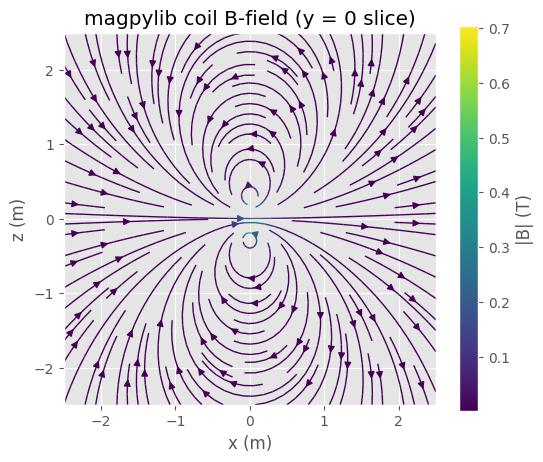

In [67]:
Bx_slice = Bx[:, 0, :]
Bz_slice = Bz[:, 0, :]
mag = np.hypot(Bx_slice, Bz_slice).T

fig, ax = plt.subplots(figsize=(6, 5))
strm = ax.streamplot(
    coords, coords, Bx_slice.T, Bz_slice.T,
    color=mag, cmap="viridis", density=1.2, linewidth=1,
)
cb = fig.colorbar(strm.lines, ax=ax)
cb.set_label("|B| (T)")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title("magpylib coil B-field (y = 0 slice)")
ax.set_aspect("equal")
plt.show()

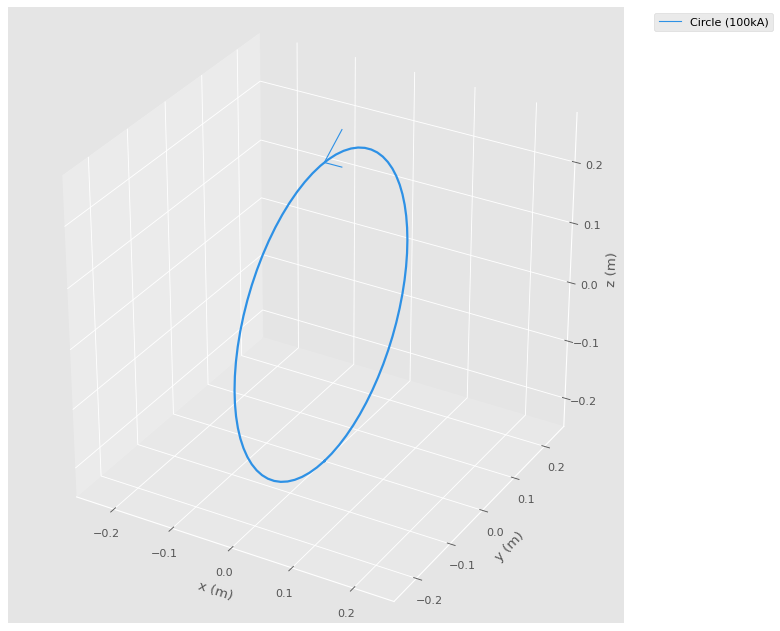

In [68]:
mp.show(C, backend="matplotlib")